# Image Segmentation based on Clustering
This idea might have come to you while reading about image segmentation. Can’t we use clustering techniques to divide images into segments? We certainly can!

In this section, we’ll get an an intuition of what clustering is (it’s always good to revise certain concepts!) and how we can use of it to segment images.

Clustering is the task of dividing the population (data points) into a number of groups, such that data points in the same groups are more similar to other data points in that same group than those in other groups. These groups are known as clusters.

One of the most commonly used clustering algorithms is k-means. Here, the k represents the number of clusters (not to be confused with k-nearest neighbor). Let’s understand how k-means works:

1. First, randomly select k initial clusters

2. Randomly assign each data point to any one of the k clusters

3. Calculate the centers of these clusters

4. Calculate the distance of all the points from the center of each cluster

5. Depending on this distance, the points are reassigned to the nearest cluster

6. Calculate the center of the newly formed clusters

7. Finally, repeat steps (4), (5) and (6) until either the center of the clusters does not change or we reach the set number of iterations

In [1]:
from skimage.color import rgb2gray
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import ndimage

(192, 263, 3)


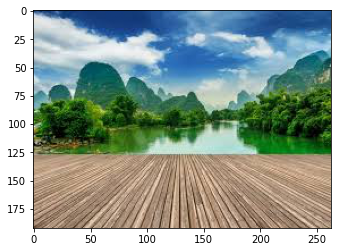

In [2]:
pic = plt.imread('/content/drive/MyDrive/KLA/1.jpeg')/255  # dividing by 255 to bring the pixel values between 0 and 1
print(pic.shape)
plt.imshow(pic)

It’s a 3-dimensional image of shape (192, 263, 3). For clustering the image using k-means, we first need to convert it into a 2-dimensional array whose shape will be (length*width, channels). In our example, this will be (192*263, 3).

In [3]:
pic_n = pic.reshape(pic.shape[0]*pic.shape[1], pic.shape[2])
pic_n.shape

(50496, 3)

We can see that the image has been converted to a 2-dimensional array. Next, fit the k-means algorithm on this reshaped array and obtain the clusters. The cluster_centers_ function of k-means will return the cluster centers and labels_ function will give us the label for each pixel (it will tell us which pixel of the image belongs to which cluster).

In [5]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0).fit(pic_n)
pic2show = kmeans.cluster_centers_[kmeans.labels_]

I have chosen 5 clusters for this article but you can play around with this number and check the results. Now, let’s bring back the clusters to their original shape, i.e. 3-dimensional image, and plot the results.

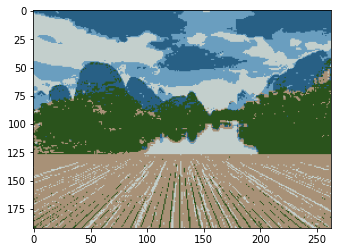

In [6]:
cluster_pic = pic2show.reshape(pic.shape[0], pic.shape[1], pic.shape[2])
plt.imshow(cluster_pic)

Amazing, isn’t it? We are able to segment the image pretty well using just 5 clusters. I’m sure you’ll be able to improve the segmentation by increasing the number of clusters.

k-means works really well when we have a small dataset. It can segment the objects in the image and give impressive results. But the algorithm hits a roadblock when applied on a large dataset (more number of images).

It looks at all the samples at every iteration, so the time taken is too high. Hence, it’s also too expensive to implement. And since k-means is a distance-based algorithm, it is only applicable to convex datasets and is not suitable for clustering non-convex clusters.